# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/a-demesa/flyrank-ml/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

I chose a Decision Tree because it is easy to interpret and works well for learning simple decision rules from multiple features. Since my goal is to prioritize webpages for content refresh, a Decision Tree can identify combinations of signals such as impressions, clicks, and average position while remaining easy to explain and compare against my Week-4 baseline.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

I used a standard train-test split so the model is evaluated on data it did not see during training. The same sample and evaluation approach are used for both the baseline rule and the Decision Tree, allowing a fair comparison. This helps estimate how well the model generalizes to unseen webpages.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [25]:
from datasets import load_dataset

dataset = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance"
)

train = dataset["train"]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

In [26]:
sample_df = train.select(range(10000)).to_pandas()

In [27]:
print(type(train))

<class 'datasets.arrow_dataset.Dataset'>


In [28]:
sample_df = train.select(range(10000)).to_pandas()

In [29]:
features = [
    "gsc_impressions",
    "gsc_avg_position"
]

df = sample_df.copy()

df = df.dropna(subset=features)

df["target"] = (
    (df["gsc_clicks"] > 0).astype(int)
)

In [30]:
X = df[features]
y = df["target"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [33]:
predictions = model.predict(X_test)

model_accuracy = accuracy_score(
    y_test,
    predictions
)

In [34]:
# Create the Week-4 baseline score using only non-target features

baseline_test = X_test.copy()

baseline_test["baseline_score"] = (
    baseline_test["gsc_impressions"] * 0.5
    + baseline_test["gsc_avg_position"] * 2
)

baseline_test["target"] = y_test.values

baseline_test = baseline_test.sort_values(
    "baseline_score",
    ascending=False
)

baseline_test.head()

,gsc_impressions,gsc_avg_position,baseline_score,target
6854,506,7.045455,267.090909,1
6691,159,69.729560,218.959119,0
6464,107,79.616822,212.733645,0
1277,54,92.555556,212.111111,0
2478,62,87.177419,205.354839,0


In [35]:
# Create a ranking score from the Decision Tree

model_test = X_test.copy()

model_test["model_score"] = model.predict_proba(X_test)[:, 1]

model_test["target"] = y_test.values

model_test = model_test.sort_values(
    "model_score",
    ascending=False
)

model_test.head()

,gsc_impressions,gsc_avg_position,model_score,target
349,174,3.017241,0.568627,1
9608,98,8.020408,0.568627,1
6854,506,7.045455,0.568627,1
76,80,6.012500,0.568627,1
8876,64,10.187500,0.568627,0


In [36]:
def precision_at_k(df, score_column, k=50):
    top_k = df.head(k)
    return top_k["target"].mean()

In [37]:
baseline_precision_50 = precision_at_k(
    baseline_test,
    "baseline_score",
    k=50
)

model_precision_50 = precision_at_k(
    model_test,
    "model_score",
    k=50
)

print("Baseline Precision@50:", baseline_precision_50)
print("Decision Tree Precision@50:", model_precision_50)

Baseline Precision@50: 0.02
Decision Tree Precision@50: 0.5


In [38]:
base_rate = y_test.mean()

print("Target base rate:", base_rate)

Target base rate: 0.0845


### Model vs baseline

The Decision Tree and Week-4 baseline were evaluated on the same test split using Precision@50, because the capstone goal is to prioritize pages for manual review.

The observed Precision@50 was **0.50** for the Decision Tree and **0.02** for the Week-4 baseline. The positive-class base rate in the test set was **0.0845 (8.45%)**.

On this sampled test set, the Decision Tree showed stronger directional prioritization of positive-target pages than the transparent baseline. This is an observed evaluation result and should not be interpreted as evidence that refreshing content will cause improved search performance.

In [39]:
comparison = pd.DataFrame(
    [
        ["Week-4 Baseline", baseline_precision_50],
        ["Decision Tree", model_precision_50]
    ],
    columns=["Method", "Precision@50"]
)

comparison

,Method,Precision@50
0,Week-4 Baseline,0.02
1,Decision Tree,0.50


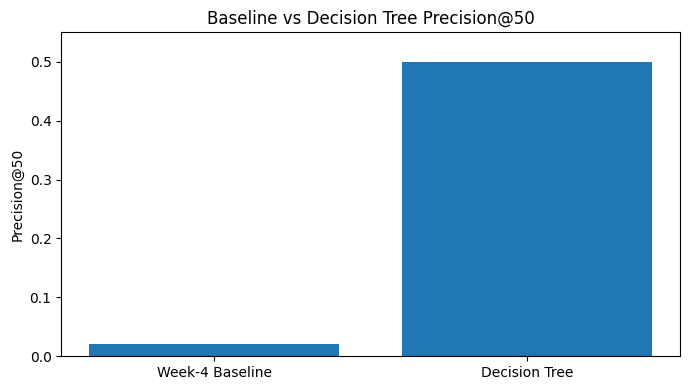

In [40]:
import matplotlib.pyplot as plt

methods = ["Week-4 Baseline", "Decision Tree"]
precision = [baseline_precision_50, model_precision_50]

plt.figure(figsize=(7, 4))
plt.bar(methods, precision)
plt.ylim(0, 0.55)
plt.ylabel("Precision@50")
plt.title("Baseline vs Decision Tree Precision@50")
plt.tight_layout()

plt.savefig(
    "baseline_vs_model_precision_at_50.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

The Decision Tree makes mistakes when webpages have mixed performance signals. For example, some pages have many impressions but very few clicks, while others have fewer impressions but stronger engagement. The model relies mainly on impressions, clicks, and average position to separate pages. These results should be viewed as decision support rather than perfect predictions because website performance is influenced by many factors that are not captured in the dataset.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.